# Baseline backtest

This notebook visualizes baseline predictions from the reusable backtest module. Core backtest logic lives in `src/training/backtest.py`, not in this notebook.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [5]:
import matplotlib.pyplot as plt
import polars as pl
import yaml

from src.training import backtest

cfg = yaml.safe_load(open(PROJECT_ROOT / "config" / "config.yaml"))

cols = [
    "station_id",
    "hour",
    "trips",
    "lag_168",
    "day_of_week",
    "hour_of_day",
]

df = pl.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "features.parquet",
    columns=cols,
)

results = backtest.run_backtest(
    df,
    [backtest.SeasonalNaive(), backtest.HistoricalMean()],
    n_windows=cfg["backtest"]["n_windows"],
)

summary = backtest.summarize(results)
summary

predictor,mae_mean,mae_std,rmse_mean,mase_mean
str,f64,f64,f64,f64
"""historical_mean""",1.198,0.316,2.267,0.82
"""seasonal_naive""",1.46,0.385,2.673,1.0


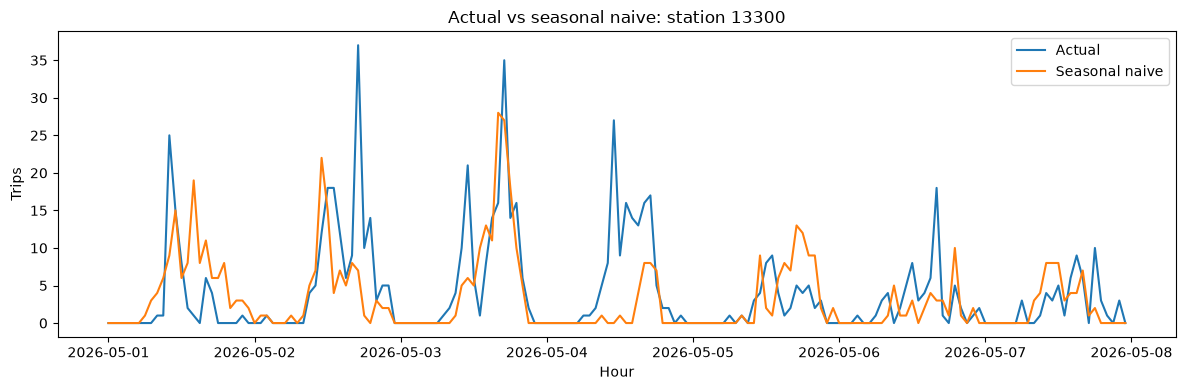

In [6]:
station_id = df.group_by("station_id").agg(pl.col("trips").sum().alias("total")).sort(
    "total",
    descending=True,
)["station_id"][0]

plot_df = (
    df.filter(pl.col("station_id") == station_id)
    .filter(pl.col("hour").is_between(pl.datetime(2026, 5, 1), pl.datetime(2026, 5, 7, 23)))
    .select("hour", "trips", "lag_168")
    .to_pandas()
)

plt.figure(figsize=(12, 4))
plt.plot(plot_df["hour"], plot_df["trips"], label="Actual")
plt.plot(plot_df["hour"], plot_df["lag_168"], label="Seasonal naive")
plt.title(f"Actual vs seasonal naive: station {station_id}")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend()
plt.tight_layout()
plt.show()

## Baseline visualization

Conclusion: The seasonal naive baseline captures repeated weekly structure but cannot adjust to weather, holidays, unusual demand shocks, or station-specific recent changes. This makes it a useful minimum benchmark for Week 3 models: any learned model should beat this baseline consistently across rolling-origin windows.